# **Loading Libraries**

In [1]:
!git clone https://github.com/Neural-GPT/Medical-Rag-Chatbot.git

Cloning into 'Medical-Rag-Chatbot'...
remote: Enumerating objects: 100, done.
remote: Counting objects: 100% (100/100), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 100 (delta 44), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (100/100), 6.06 MiB | 10.03 MiB/s, done.
Resolving deltas: 100% (44/44), done.


In [4]:
import os
os.chdir("/content/Medical-Rag-Chatbot")

In [5]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 101.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 6.7 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.0 which is incompatible.


In [1]:
import os
import sys
import requests
import pandas as pd
from tqdm import tqdm
from groq import Groq

from langchain_community.vectorstores import FAISS
from langchain_core.prompts import ChatPromptTemplate
from langchain_huggingface import HuggingFaceEmbeddings

from langchain_community.document_loaders import DataFrameLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [5]:
from src.preprocessing import load_data, split_docs
from src.vector import retrieve, generate_vector_store
from src.ask_rag import ask_rag


# **Pre Processing**

In [9]:
data_path = "data/pubmed_diabetes_1000_meta.csv"

documents = load_data(data_path, DataFrameLoader)
text = split_docs(documents, RecursiveCharacterTextSplitter, chunk_size = 350, chunk_overlap = 50) # changing chunk_size to 350

Total document chunks created: 6223


In [11]:
generator = HuggingFaceEmbeddings(model_name = "BAAI/bge-small-en-v1.5", model_kwargs = {"device":"cpu"})
vector_db_path = "/content/Vector_db_350" # create path to store new embeddings

vector_store = generate_vector_store(generator, vector_db_path, text, FAISS)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [23]:
query = "What are the causes of diabetes?"
retriever = vector_store.as_retriever(search_type = "mmr", k = 4, fetch_k = 8, lambda_mult = 0.3)

context = retrieve(query, retriever)

for c in context:
  print(f"{c}\n")

The prevalence of diabetes and its related complications are increasing significantly globally. Collected evidence suggested that several genetic and environmental factors contribute to diabetes mellitus. Associated complications such as retinopathy, neuropathy, nephropathy and other cardiovascular complications are a direct result of diabetes.

diabetes patients, which might be one of the reasons for the onset of type 2 diabetes.

Diabetes is the most frequent cause of chronic kidney disease (CKD), leading to nearly half of all cases of kidney failure requiring replacement therapy. The principal cause of death among patients with diabetes and CKD is cardiovascular disease (CVD). Sodium/glucose cotransporter 2 (SGLT2) inhibitors were developed to lower blood glucose levels by

Type 1 diabetes (T1D) is the most common cause of diabetes in childhood but type 2 diabetes (T2D) and maturity onset diabetes of the young (MODY) are emerging as noteworthy causes of diabetes at young ages. The a

In [ ]:
''' 600 chunk size retrieved docs were better:

Diabetes mellitus (DM) is associated with several microvascular and macrovascular complications, such as retinopathy, nephropathy, neuropathy, and cardiovascular diseases. The pathogenesis of these complications is complex, and involves metabolic and hemodynamic disturbances, including hyperglycemia, insulin resistance, dyslipidemia, hypertension, and immune dysfunction. These disturbances initiate several damaging processes, such as increased reactive oxygen species (ROS) production, inflammation, and ischemia. These processes mainly exert their damaging effect on endothelial and nerve cells,

Type 1 diabetes (T1D) is the most common cause of diabetes in childhood but type 2 diabetes (T2D) and maturity onset diabetes of the young (MODY) are emerging as noteworthy causes of diabetes at young ages. The aim is to determine the distribution, trends and clinical features of the different types of diabetes in childhood in one tertiary center.

regulatory mechanisms of diabetes and explained how viral infections can also trigger the onset of diabetes.

Type 2 Diabetes Mellitus (T2DM), one of the most common metabolic disorders, is caused by a combination of two primary factors: defective insulin secretion by pancreatic β-cells and the inability of insulin-sensitive tissues to respond appropriately to insulin. Because insulin release and activity are essential processes for glucose homeostasis, the molecular mechanisms involved in the synthesis and release of insulin, as well as in its detection are tightly regulated. Defects in any of the mechanisms involved in these processes can lead to a metabolic imbalance responsible for the development
'''

# **Models**

In [13]:
with open("/content/GROQ_API_KEY.txt") as f: # use your own API key (txt format)
    os.environ["GROQ_API_KEY"] = f.read().strip()

client = Groq(api_key = os.environ["GROQ_API_KEY"])

model = "llama-3.1-8b-instant"

template = """
    "You are an assistant for question-answering tasks. "
    "Use the following pieces of retrieved context to answer "
    "the question. If you don't know the answer, say that you "
    "don't know. Use 3-4 sentences maximum but "
    "don't inject noise. Conclude the answer the way question is asked, "
    "list aLL necessary information mentioned, "
    "do not generalize or omit details"


    Context:
    {context}

    Question:
    {question}

    Answer:
"""

query = "What is diabetes?"

In [14]:
ask_rag(query, retriever, template, client, model)

"Diabetes mellitus, commonly referred to as diabetes, is a combination of many metabolic diseases. \n\nNecessary information mentioned:\n- Common terms used for diabetes: Diabetes mellitus, diabetes\n- Description: It's a combination of many metabolic diseases\n- Main cause: Insulin deficiency\n- Worldwide impact: Globally causing over 3.2 million adult deaths per year\n\nNote: The answer to your question is in the given context as 'Diabetes mellitus, commonly referred to as diabetes, is a combination of many metabolic diseases.'"

In [ ]:
"""
Response for same query but 350 chunk size:

Diabetes mellitus, commonly referred to as diabetes, is a combination of many metabolic diseases.

Necessary information mentioned:
- Common terms used for diabetes: Diabetes mellitus, diabetes
- Description: It's a combination of many metabolic diseases
- Main cause: Insulin deficiency
- Worldwide impact: Globally causing over 3.2 million adult deaths per year

Note: The answer to your question is in the given context as 'Diabetes mellitus, commonly referred to as diabetes, is a combination of many metabolic diseases.'

=======================================================================================================================

Response for same query by same model but 600 chunk size retrieved doocs was:

Diabetes mellitus, commonly referred to as diabetes, is a combination of many metabolic diseases. It is caused by insulin deficiency in the body, where insulin
is one of the most well-studied proteins.

Information mentioned:
- Diabetes mellitus
- Combination of many metabolic diseases
- Main cause: insulin deficiency
- Diabetes mellitus is also referred to as diabetes

"""

In [26]:
ask_rag(query, retriever1, template, client, model)

'The causes of diabetes according to the given context are multifaceted. Type 1 diabetes is associated with defective pancreatic β-cells, while Type 2 diabetes is caused by a combination of two primary factors: defective insulin secretion by pancreatic β-cells and the inability of insulin-sensitive tissues to respond appropriately to insulin. In addition to these, viral infections can trigger the onset of diabetes.\n\nInformation mentioned:\n- Type 1 diabetes\n- Type 2 diabetes\n- Defective pancreatic β-cells\n- Defective insulin secretion\n- Inability of insulin-sensitive tissues to respond to insulin\n- Viral infections'

In [ ]:
"""
Response for same query by llMama 3.1 8b but 600 size retriever:

The causes of diabetes according to the given context are multifaceted. Type 1 diabetes is associated with defective pancreatic β-cells, while Type 2 diabetes
is caused by a combination of two primary factors: defective insulin secretion by pancreatic β-cells and the inability of insulin-sensitive tissues to
respond appropriately to insulin. In addition to these, viral infections can trigger the onset of diabetes.

Information mentioned:
- Type 1 diabetes
- Type 2 diabetes
- Defective pancreatic β-cells
- Defective insulin secretion
- Inability of insulin-sensitive tissues to respond to insulin
- Viral infections

In [19]:
# now i'll change the llm model from llama-3.1-8b-instant to qwen/qwen3-32b

model1 = "qwen/qwen3-32b"

ask_rag(query, retriever, template, client, model1)

'<think>\nOkay, the user is asking, "What is diabetes?" I need to use the provided context to form an answer. Let me read through the context again.\n\nFirst part says diabetes is a combination of many metabolic diseases, and the main cause is insulin deficiency. Insulin is a well-studied protein. Then there\'s mention of it being a major public health issue, causing over 3.2 million deaths annually, especially in Sub-Saharan Africa. The complications listed include nephropathy, retinopathy, cardiomyopathy, and other cardiovascular diseases. Also, NLRP3 inflammasome is mentioned in relation to diabetes.\n\nThe user wants a concise answer, 3-4 sentences, with all necessary information, no generalizations or omissions. Need to list all mentioned points: definition, insulin deficiency, public health burden with death stats, regions affected, complications, and the NLRP3 inflammasome part. Wait, does the context say NLRP3 is part of diabetes or related to complications? The sentence is cut

In [ ]:
"""
Answer by qwen3-32b for same query, at 350 size retriever:

Diabetes is a combination of metabolic diseases primarily caused by insulin deficiency. It globally claims over 3.2 million adult lives annually, disproportionately
affecting Sub-Saharan Africa, and leads to complications like nephropathy, retinopathy, cardiomyopathy, and cardiovascular/cerebrovascular diseases.
The NLRP3 inflammasome is implicated in its pathogenesis or associated inflammatory mechanisms.

"""

In [ ]:
# now qwen3-32b model, same query but using 600 size retriever

In [24]:
vector_db_path = "/content/Medical-Rag-Chatbot/src/Vector_db_600" # using pre built vector db from repo
vector_store1 = generate_vector_store(generator, vector_db_path, text, FAISS)

retriever1 = vector_store1.as_retriever(search_type = "mmr", k = 4, fetch_k = 8, lambda_mult = 0.3)
context = retrieve(query, retriever1)

for c in context:
  print(f"{c}\n")

Diabetes mellitus (DM) is associated with several microvascular and macrovascular complications, such as retinopathy, nephropathy, neuropathy, and cardiovascular diseases. The pathogenesis of these complications is complex, and involves metabolic and hemodynamic disturbances, including hyperglycemia, insulin resistance, dyslipidemia, hypertension, and immune dysfunction. These disturbances initiate several damaging processes, such as increased reactive oxygen species (ROS) production, inflammation, and ischemia. These processes mainly exert their damaging effect on endothelial and nerve cells,

Type 1 diabetes (T1D) is the most common cause of diabetes in childhood but type 2 diabetes (T2D) and maturity onset diabetes of the young (MODY) are emerging as noteworthy causes of diabetes at young ages. The aim is to determine the distribution, trends and clinical features of the different types of diabetes in childhood in one tertiary center.

regulatory mechanisms of diabetes and explained

In [25]:
ask_rag(query, retriever1, template, client, model1)

"<think>\nOkay, let's tackle the user's question: What are the causes of diabetes?\n\nFirst, I need to look at the provided context. The context mentions Type 1 Diabetes (T1D) is the most common in childhood but also notes Type 2 Diabetes (T2D) and MODY are emerging. So causes might vary by type.\n\nFor T1D, the context says it's an autoimmune destruction of β-cells, leading to insulin deficiency. The regulatory mechanisms are mentioned, and viral infections can trigger it. That's important to include.\n\nT2D, on the other hand, is caused by defective insulin secretion and insulin resistance in tissues. The context explains it's due to issues in insulin release and activity in glucose homeostasis. So I should note the two main factors here.\n\nMODY is a genetic form mentioned in the third paragraph. Since the user's question is general but the context includes MODY, I should mention that as a cause as well, though it's less common.\n\nThe context also touches on microvascular and macro

In [ ]:
"""
Answer by qwen3 32b on same query but using 600 chunk size retrieve:

Diabetes is caused by distinct mechanisms depending on the type. Type 1 diabetes (T1D) results from autoimmune destruction of pancreatic β-cells, leading to insulin
deficiency, and may be triggered by viral infections. Type 2 diabetes (T2D) arises from defective insulin secretion and insulin resistance in tissues.
Other causes include genetic factors in maturity-onset diabetes of the young (MODY) and metabolic disturbances such as hyperglycemia, insulin resistance,
dyslipidemia, and hypertension contributing to disease progression.

"""

# **Evaluation of Experiments**

In [ ]:
# llama-3.1-8b-instant using 350 size retriever
# rated 2.2 overall by LLM as Judge (ChatGPT)

query = "What is diabetes?"
context = "The prevalence of diabetes and its related complications are increasing significantly globally. Collected evidence suggested that several genetic and environmental factors contribute to diabetes mellitus. Associated complications such as retinopathy, neuropathy, nephropathy and other cardiovascular complications are a direct result of diabetes. diabetes patients, which might be one of the reasons for the onset of type 2 diabetes. Diabetes is the most frequent cause of chronic kidney disease (CKD), leading to nearly half of all cases of kidney failure requiring replacement therapy. The principal cause of death among patients with diabetes and CKD is cardiovascular disease (CVD). Sodium/glucose cotransporter 2 (SGLT2) inhibitors were developed to lower blood glucose levels by. Type 1 diabetes (T1D) is the most common cause of diabetes in childhood but type 2 diabetes (T2D) and maturity onset diabetes of the young (MODY) are emerging as noteworthy causes of diabetes at young ages. The aim is to determine the distribution, trends and clinical features of the different types of diabetes in childhood in one tertiary center."
main_response = "The answer to your question is in the given context as 'Diabetes mellitus, commonly referred to as diabetes, is a combination of many metabolic diseases.'

In [ ]:
# llama-3.1-8b-instant using 600 size retriever
# rated 5.8 overall by LLM as Judge (ChatGPT)

query = "What is diabetes?"
context = "Diabetes mellitus (DM) is associated with several microvascular and macrovascular complications, such as retinopathy, nephropathy, neuropathy, and cardiovascular diseases. The pathogenesis of these complications is complex, and involves metabolic and hemodynamic disturbances, including hyperglycemia, insulin resistance, dyslipidemia, hypertension, and immune dysfunction. These disturbances initiate several damaging processes, such as increased reactive oxygen species (ROS) production, inflammation, and ischemia. These processes mainly exert their damaging effect on endothelial and nerve cells, Type 1 diabetes (T1D) is the most common cause of diabetes in childhood but type 2 diabetes (T2D) and maturity onset diabetes of the young (MODY) are emerging as noteworthy causes of diabetes at young ages. The aim is to determine the distribution, trends and clinical features of the different types of diabetes in childhood in one tertiary center. regulatory mechanisms of diabetes and explained how viral infections can also trigger the onset of diabetes. Type 2 Diabetes Mellitus (T2DM), one of the most common metabolic disorders, is caused by a combination of two primary factors: defective insulin secretion by pancreatic β-cells and the inability of insulin-sensitive tissues to respond appropriately to insulin. Because insulin release and activity are essential processes for glucose homeostasis, the molecular mechanisms involved in the synthesis and release of insulin, as well as in its detection are tightly regulated. Defects in any of the mechanisms involved in these processes can lead to a metabolic imbalance responsible for the development"
main_response = "The causes of diabetes according to the given context are multifaceted. Type 1 diabetes is associated with defective pancreatic β-cells, while Type 2 diabetes is caused by a combination of two primary factors: defective insulin secretion by pancreatic β-cells and the inability of insulin-sensitive tissues to respond appropriately to insulin. In addition to these, viral infections can trigger the onset of diabetes."

In [ ]:
# qwen3-32b using 350 size retriever
# rated 3.6 overall by LLM as Judge (ChatGPT)

query = "What is diabetes?"
context = "The prevalence of diabetes and its related complications are increasing significantly globally. Collected evidence suggested that several genetic and environmental factors contribute to diabetes mellitus. Associated complications such as retinopathy, neuropathy, nephropathy and other cardiovascular complications are a direct result of diabetes. diabetes patients, which might be one of the reasons for the onset of type 2 diabetes. Diabetes is the most frequent cause of chronic kidney disease (CKD), leading to nearly half of all cases of kidney failure requiring replacement therapy. The principal cause of death among patients with diabetes and CKD is cardiovascular disease (CVD). Sodium/glucose cotransporter 2 (SGLT2) inhibitors were developed to lower blood glucose levels by. Type 1 diabetes (T1D) is the most common cause of diabetes in childhood but type 2 diabetes (T2D) and maturity onset diabetes of the young (MODY) are emerging as noteworthy causes of diabetes at young ages. The aim is to determine the distribution, trends and clinical features of the different types of diabetes in childhood in one tertiary center."
main_response = "Diabetes is a combination of metabolic diseases primarily caused by insulin deficiency. It globally claims over 3.2 million adult lives annually, disproportionately affecting Sub-Saharan Africa, and leads to complications like nephropathy, retinopathy, cardiomyopathy, and cardiovascular/cerebrovascular diseases. The NLRP3 inflammasome is implicated in its pathogenesis or associated inflammatory mechanisms."


In [ ]:
# qwen3-32b using 600 size retriever
# rated 6.2 overall by LLM as Judge (ChatGPT)

query = "What is diabetes?"
context = "Diabetes mellitus (DM) is associated with several microvascular and macrovascular complications, such as retinopathy, nephropathy, neuropathy, and cardiovascular diseases. The pathogenesis of these complications is complex, and involves metabolic and hemodynamic disturbances, including hyperglycemia, insulin resistance, dyslipidemia, hypertension, and immune dysfunction. These disturbances initiate several damaging processes, such as increased reactive oxygen species (ROS) production, inflammation, and ischemia. These processes mainly exert their damaging effect on endothelial and nerve cells, Type 1 diabetes (T1D) is the most common cause of diabetes in childhood but type 2 diabetes (T2D) and maturity onset diabetes of the young (MODY) are emerging as noteworthy causes of diabetes at young ages. The aim is to determine the distribution, trends and clinical features of the different types of diabetes in childhood in one tertiary center. regulatory mechanisms of diabetes and explained how viral infections can also trigger the onset of diabetes. Type 2 Diabetes Mellitus (T2DM), one of the most common metabolic disorders, is caused by a combination of two primary factors: defective insulin secretion by pancreatic β-cells and the inability of insulin-sensitive tissues to respond appropriately to insulin. Because insulin release and activity are essential processes for glucose homeostasis, the molecular mechanisms involved in the synthesis and release of insulin, as well as in its detection are tightly regulated. Defects in any of the mechanisms involved in these processes can lead to a metabolic imbalance responsible for the development"
main_response = "Diabetes is caused by distinct mechanisms depending on the type. Type 1 diabetes (T1D) results from autoimmune destruction of pancreatic β-cells, leading to insulin deficiency, and may be triggered by viral infections. Type 2 diabetes (T2D) arises from defective insulin secretion and insulin resistance in tissues. Other causes include genetic factors in maturity-onset diabetes of the young (MODY) and metabolic disturbances such as hyperglycemia, insulin resistance, dyslipidemia, and hypertension contributing to disease progression."

# **Final Improvements**

In [29]:
generator = HuggingFaceEmbeddings(model_name = "BAAI/bge-small-en-v1.5", model_kwargs = {"device":"cpu"})
vector_db_path = "/content/Vector_db_850_small" # create path to store new embeddings

vector_store = generate_vector_store(generator, vector_db_path, text, FAISS)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [33]:
retriever = vector_store.as_retriever(search_type = "mmr", fetch_k = 10, k = 4, lambda_mult = 0.75)
query = "What is diabetes?"
context = retrieve(query, retriever)

for c in context:
  print(f"{c}\n")

Background: Diabetes is referred to a group of diseases characterized by high glucose levels in blood. It is caused by a deficiency in the production or function of insulin or both, which can occur because of different reasons, resulting in protein and lipid metabolic disorders. The aim of this study was to systematically review the prevalence and incidence of type 1 diabetes in the world.

People with psychiatric disorders have increased risk of premature death partly due to diabetes. This study aims to explore the quality of diabetes care, diabetes management, diabetes support and well-being of people with psychiatric disorders and diabetes.

Type 2 diabetes mellitus (T2DM) is the most widespread form of diabetes, characterized by chronic hyperglycaemia, insulin resistance, and inefficient insulin secretion and action. Primary care in T2DM is pharmacological, using drugs of several groups that include insulin sensitisers (e.g., biguanides, thiazolidinediones), insulin secretagogues (

In [34]:
temp1 = """
    "You are a medical Q&A assistant. Answer the question using ONLY the provided context."
    "Be concise and accurate. If the context doesn't contain the answer, say I don't know."
    "Do not add information beyond what is in the context."

    Context: {context}
    Question: {question}
    Answer:
      """

query = "What is diabetes"
m1 = "qwen/qwen3-32b"
ask_rag(query, retriever, temp1, client, m1)

'<think>\nOkay, let me try to figure out how to answer the question "What is diabetes?" based on the provided context. \n\nFirst, I need to look through the context given. The first paragraph under the Background section says: "Diabetes is referred to a group of diseases characterized by high glucose levels in blood. It is caused by a deficiency in the production or function of insulin or both, which can occur because of different reasons, resulting in protein and lipid metabolic disorders." That seems like the key part here.\n\nThe other parts of the context talk about studies on prevalence, people with psychiatric disorders, cancer prevention, and public health in Africa. But those don\'t directly define diabetes. The question is asking for the definition or explanation of diabetes. So the answer should be based on the first part of the context provided.\n\nI should check if there\'s any other mention of diabetes in the context that could help. Scanning through, the rest is about dif

In [ ]:
"""
Response:

Diabetes is a group of diseases characterized by high glucose levels in the blood, caused by a deficiency in the production or function of insulin or both,
leading to protein and lipid metabolic disorders."""

In [ ]:
# qwen3 32b with 850 chunk size retriever, lambda mult = 0.75, simpler template, rated 9.6 by ChatGPT

query = "What is diabetes"
context = "Background: Diabetes is referred to a group of diseases characterized by high glucose levels in blood. It is caused by a deficiency in the production or function of insulin or both, which can occur because of different reasons, resulting in protein and lipid metabolic disorders. The aim of this study was to systematically review the prevalence and incidence of type 1 diabetes in the world.People with psychiatric disorders have increased risk of premature death partly due to diabetes. This study aims to explore the quality of diabetes care, diabetes management, diabetes support and well-being of people with psychiatric disorders and diabetes.Type 2 diabetes mellitus (T2DM) is the most widespread form of diabetes, characterized by chronic hyperglycaemia, insulin resistance, and inefficient insulin secretion and action. Primary care in T2DM is pharmacological, using drugs of several groups that include insulin sensitisers (e.g., biguanides, thiazolidinediones), insulin secretagogues (e.g., sulphonylureas, meglinides), alpha-glucosidase inhibitors, and the newest incretin-based therapies and sodium–glucose co-transporter 2 inhibitors. However, their long-term application can cause many harmful side effects, emphasising the importance of the using natural therapeutic products. Natural health substances including non-flavonoid polyphenols (e.g., resveratrol, curcumin, tannins, and lignans), flavonoids (e.g., anthocyanins, epigallocatechin gallate, quercetin, naringin, rutin, andDiabetes mellitus is a metabolic disorder resulting from either loss of insulin producing cells, insufficient insulin action, or both. Knowledge can play an important role in preventing diabetes mellitus and its complications. There is limited information regarding knowledge and related factors regarding diabetes mellitus among non-diabetic adult community members in the study area. Therefore, the current study aimed to determine knowledge and associated factors towards diabetes mellitus among non-diabetes community members of Gondar city."
response = "Diabetes is a group of diseases characterized by high glucose levels in the blood, caused by a deficiency in the production or function of insulin or both, leading to protein and lipid metabolic disorders."

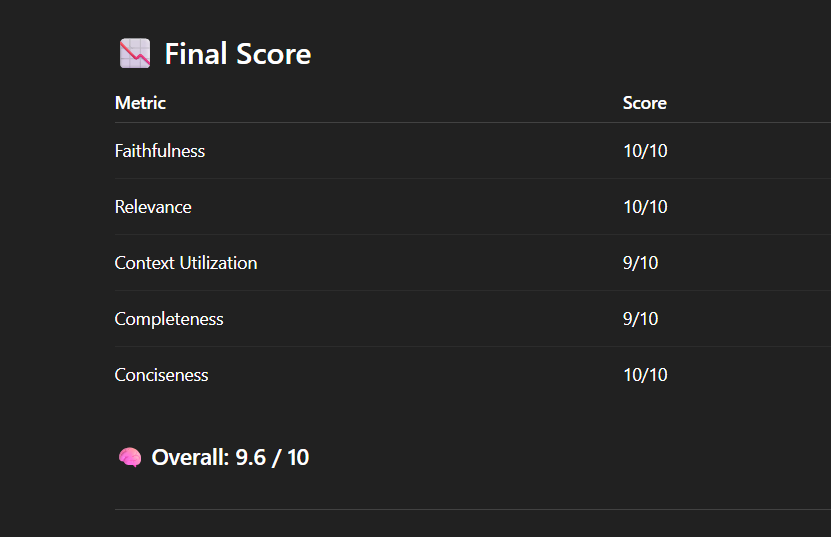

In [35]:
query = "what are the causes of diabetes?"
retrieve(query, retriever)


['Background: Diabetes is referred to a group of diseases characterized by high glucose levels in blood. It is caused by a deficiency in the production or function of insulin or both, which can occur because of different reasons, resulting in protein and lipid metabolic disorders. The aim of this study was to systematically review the prevalence and incidence of type 1 diabetes in the world.',
 'Diabetes mellitus is becoming more prevalent and even with new advancements which improve glycaemic control, complications of diabetes are common. Vascular complications of diabetes include the microvascular complications: retinopathy, nephropathy, and peripheral and autonomic neuropathy. Macrovascular complications are also common in patients with diabetes and arguably more concerning as they confer a high mortality risk yet are sometimes under-treated. Risk factors for diabetes complications start to occur in childhood and adolescents and some youths may be diagnosed with complications before

In [36]:
ask_rag(query, retriever, temp1, client, m1)

"<think>\nOkay, the user is asking about the causes of diabetes. Let me check the provided context. The context mentions that diabetes is a group of diseases characterized by high glucose levels. It states that the causes can be a deficiency in production or function of insulin, or both. It also notes that different reasons lead to insulin issues, resulting in metabolic disorders.\n\nLooking at the context, there's a part about high salt intake possibly causing diabetes by lowering interstitial fluid pH and causing insulin resistance, though the molecular mechanism is unclear. Another part talks about factors like age, alcohol drinking, HDL, triglycerides, and physical activity being associated with diabetes in Addis Ababa. However, the main causes mentioned are insulin production or function deficiencies.\n\nThe user's question is about causes, so I need to stick to the information in the context. The context doesn't mention genetic factors, pancreatitis, or other causes, so I shouldn

In [ ]:
query = "what are the causes of diabetes?"
context = ['Background: Diabetes is referred to a group of diseases characterized by high glucose levels in blood. It is caused by a deficiency in the production or function of insulin or both, which can occur because of different reasons, resulting in protein and lipid metabolic disorders. The aim of this study was to systematically review the prevalence and incidence of type 1 diabetes in the world.',
 'Diabetes mellitus is becoming more prevalent and even with new advancements which improve glycaemic control, complications of diabetes are common. Vascular complications of diabetes include the microvascular complications: retinopathy, nephropathy, and peripheral and autonomic neuropathy. Macrovascular complications are also common in patients with diabetes and arguably more concerning as they confer a high mortality risk yet are sometimes under-treated. Risk factors for diabetes complications start to occur in childhood and adolescents and some youths may be diagnosed with complications before transition to adult care. This article discusses the prevalence, risk factors, screening, and treatment recommendations for vascular complications in children and adolescents with diabetes.',
 'has been suggested to cause diabetes mellitus; however, the molecular mechanism is unclear. A possible mechanism of high salt intake-caused diabetes mellitus is proposed from a viewpoint of regulation of the interstitial fluid pH: high salt intake lowers the interstitial fluid pH via high production of H+ associated with ATP synthesis required for the Na+,K+-ATPase to extrude the high leveled intracellular Na+ caused by high salt intake. This review article introduces the molecular mechanism causing the lowered interstitial fluid pH and insulin resistance in diabetes mellitus, the improvement of insulin resistance via intake of weak organic acid-containing foods, and a proposal mechanism of high salt intake-caused diabetes mellitus.',
 'A higher prevalence of diabetes mellitus was observed in Addis Ababa public health institutions.\xa0Factors such as age, alcohol drinking, HDL, triglycerides, and vagarious physical activity were associated with diabetes mellitus. Concerned bodies need to work over the ever-increasing diabetes mellitus in Addis Ababa.']
response = "Diabetes is caused by a deficiency in the production or function of insulin, or both, leading to high glucose levels in the blood. The context also mentions"
"high salt intake as a potential contributor, which may lower interstitial fluid pH and cause insulin resistance (though the molecular mechanism is unclear). "
"Additional factors associated with diabetes include age, alcohol consumption, triglyceride levels, HDL, and physical activity."

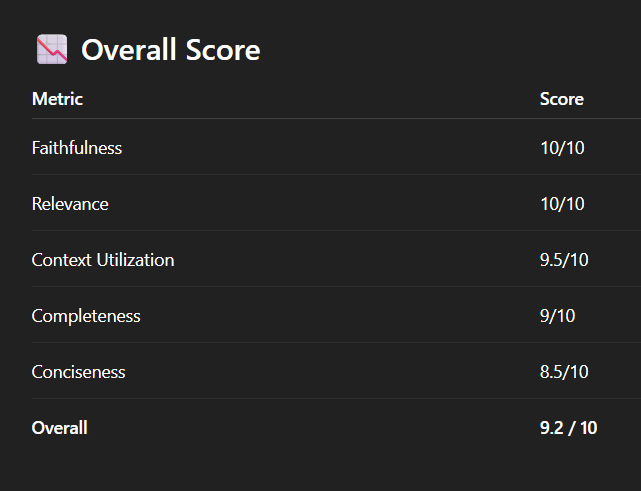